# Out-of-Context Experiment

Treino e avaliacao reproduziveis do detector que usa somente a relacao semantica entre `system_prompt` e `user_prompt`.

In [1]:
from concurrent.futures import ThreadPoolExecutor, as_completed
import os
from pathlib import Path
import json
import re
from time import perf_counter

from datasets import load_dataset
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.frozen import FrozenEstimator
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
 )
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

SEED = 42
EMBEDDING_MODEL_NAME = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
EMBEDDING_DIMENSION = 384
FEATURE_DIMENSION = EMBEDDING_DIMENSION * 2 + 3
LATENCY_REPEATS = 5
HF_DATASET_NAME = "gabrielchua/off-topic"
TARGET_COLUMN = "target"
OFF_TOPIC_SAMPLE_SIZE = 10_000
OFF_TOPIC_SHUFFLE_BUFFER = 100_000
FINAL_SAMPLE_SIZE = 10_000
MAX_CANDIDATE_WORKERS = min(3, os.cpu_count() or 1)

cwd = Path.cwd().resolve()
PROJECT_ROOT = next(path for path in (cwd, *cwd.parents) if (path / "data").exists())
RESULTS_DIR = PROJECT_ROOT / "experiments" / "out_of_context" / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

OUT_OF_CONTEXT_PARQUET_PATH = PROJECT_ROOT / "data" / "out-of-context.parquet"
OFF_TOPIC_PARQUET_PATH = PROJECT_ROOT / "data" / "off-topic.parquet"
MERGED_SAMPLE_PARQUET_PATH = PROJECT_ROOT / "data" / "out-of-context-plus-off-topic-10k.parquet"


def encode_prompts(model, prompts, batch_size=64, show_progress_bar=False):
    unique_prompts = list(dict.fromkeys(prompts))
    unique_embeddings = model.encode(
        unique_prompts,
        batch_size=batch_size,
        show_progress_bar=show_progress_bar,
        convert_to_numpy=True,
    ).astype(np.float32)
    embedding_by_prompt = dict(zip(unique_prompts, unique_embeddings, strict=True))
    return np.vstack([embedding_by_prompt[prompt] for prompt in prompts])


def jaccard_distance(left, right):
    left_tokens = set(re.findall(r"\w+", left.lower()))
    right_tokens = set(re.findall(r"\w+", right.lower()))
    union = left_tokens | right_tokens
    if not union:
        return 0.0
    return 1.0 - len(left_tokens & right_tokens) / len(union)


def preprocess_prompt_pairs(system_prompts, user_prompts, model, batch_size=64, show_progress_bar=False):
    system_embeddings = encode_prompts(model, system_prompts, batch_size, show_progress_bar)
    user_embeddings = encode_prompts(model, user_prompts, batch_size, show_progress_bar)
    difference = system_embeddings - user_embeddings
    absolute_difference = np.abs(difference)
    dot_product = np.sum(system_embeddings * user_embeddings, axis=1, keepdims=True)
    system_norm = np.linalg.norm(system_embeddings, axis=1, keepdims=True)
    user_norm = np.linalg.norm(user_embeddings, axis=1, keepdims=True)
    jaccard_distances = np.asarray([
        jaccard_distance(system_prompt, user_prompt)
        for system_prompt, user_prompt in zip(system_prompts, user_prompts, strict=True)
    ], dtype=np.float32).reshape(-1, 1)
    features = np.hstack([
        user_embeddings,
        absolute_difference,
        dot_product / np.maximum(system_norm * user_norm, 1e-12),
        jaccard_distances,
        dot_product,
    ]).astype(np.float32)
    assert features.shape[1] == FEATURE_DIMENSION
    return features


def metrics_at_threshold(y_true, probabilities, threshold):
    predictions = (probabilities >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, predictions, labels=[0, 1]).ravel()
    return {
        "threshold": float(threshold),
        "accuracy": accuracy_score(y_true, predictions),
        "precision": precision_score(y_true, predictions, zero_division=0),
        "recall": recall_score(y_true, predictions, zero_division=0),
        "f1": f1_score(y_true, predictions, zero_division=0),
        "false_positive_rate": fp / (fp + tn) if fp + tn else 0.0,
        "false_negative_rate": fn / (fn + tp) if fn + tp else 0.0,
        "false_positives": int(fp),
        "false_negatives": int(fn),
    }


def select_threshold(y_true, probabilities):
    table = pd.DataFrame(
        metrics_at_threshold(y_true, probabilities, threshold)
        for threshold in np.linspace(0.001, 0.999, 999)
    )
    operating_points = table[table["precision"].gt(0) & table["recall"].gt(0)]
    selected = (
        operating_points.assign(
            precision_recall_gap=(operating_points["precision"] - operating_points["recall"]).abs()
        )
        .sort_values(
            ["precision_recall_gap", "f1", "threshold"],
            ascending=[True, False, False],
        )
        .iloc[0]
    )
    return float(selected["threshold"]), table


def measure_prediction_latency(model, features, repeats=LATENCY_REPEATS):
    model.predict_proba(features[: min(32, len(features))])
    durations = []
    for _ in range(repeats):
        started_at = perf_counter()
        model.predict_proba(features)
        durations.append(perf_counter() - started_at)
    return float(np.median(durations) * 1000 / len(features))

RESULTS_DIR

PosixPath('/home/patotricks15/prompt_injection_detector/experiments/out_of_context/results')

## Dataset

> Fluxo deste experimento: usar `out-of-context.parquet` + criar `off-topic.parquet`, juntar em `system_prompt`, `user_prompt`, `target` e depois sortear 10.000 linhas aleatorias da juncao.

In [2]:
base_data = pd.read_parquet(OUT_OF_CONTEXT_PARQUET_PATH)
required_prompt_columns = {"system_prompt", "user_prompt"}
assert required_prompt_columns.issubset(base_data.columns)


def resolve_column(frame, candidates):
    lowered = {str(column).strip().lower(): str(column) for column in frame.columns}
    for candidate in candidates:
        if candidate.lower() in lowered:
            return lowered[candidate.lower()]
    raise ValueError(f"none of the candidate columns were found: {candidates}")


base_target_col = resolve_column(
    base_data,
    ["out_of_context", "target", "off_topic", "label"],
)

base_normalized = base_data[["system_prompt", "user_prompt", base_target_col]].rename(
    columns={base_target_col: TARGET_COLUMN}
).copy()
base_normalized["system_prompt"] = base_normalized["system_prompt"].fillna("").astype(str).str.strip()
base_normalized["user_prompt"] = base_normalized["user_prompt"].fillna("").astype(str).str.strip()
base_normalized[TARGET_COLUMN] = pd.to_numeric(
    base_normalized[TARGET_COLUMN], errors="coerce"
).fillna(0).astype(int)
base_normalized = base_normalized[base_normalized[TARGET_COLUMN].isin([0, 1])].reset_index(drop=True)

# Mantem um parquet limpo e consistente com o schema final esperado.
base_normalized.to_parquet(OUT_OF_CONTEXT_PARQUET_PATH, index=False)

# Carrega apenas uma amostra do HF sem baixar/materializar o dataset inteiro.
hf_stream = load_dataset(
    HF_DATASET_NAME,
    split="train",
    streaming=True,
)
hf_rows = list(
    hf_stream.shuffle(seed=SEED, buffer_size=OFF_TOPIC_SHUFFLE_BUFFER).take(
        OFF_TOPIC_SAMPLE_SIZE
    )
)
hf_frame = pd.DataFrame(hf_rows)

hf_system_col = resolve_column(hf_frame, ["system_prompt", "system", "context"])
hf_user_col = resolve_column(hf_frame, ["user_prompt", "prompt", "text", "question"])
hf_target_col = resolve_column(
    hf_frame,
    ["off_topic", "out_of_context", "label", "target"],
)

off_topic_normalized = hf_frame[[hf_system_col, hf_user_col, hf_target_col]].rename(
    columns={
        hf_system_col: "system_prompt",
        hf_user_col: "user_prompt",
        hf_target_col: TARGET_COLUMN,
    }
).copy()
off_topic_normalized["system_prompt"] = off_topic_normalized["system_prompt"].fillna("").astype(str).str.strip()
off_topic_normalized["user_prompt"] = off_topic_normalized["user_prompt"].fillna("").astype(str).str.strip()
off_topic_normalized[TARGET_COLUMN] = pd.to_numeric(
    off_topic_normalized[TARGET_COLUMN], errors="coerce"
).fillna(0).astype(int)
off_topic_normalized = off_topic_normalized[off_topic_normalized[TARGET_COLUMN].isin([0, 1])].reset_index(drop=True)
off_topic_normalized.to_parquet(OFF_TOPIC_PARQUET_PATH, index=False)

combined = pd.concat([base_normalized, off_topic_normalized], ignore_index=True)
combined = combined[
    combined["system_prompt"].ne("") & combined["user_prompt"].ne("")
]
combined = combined.sample(frac=1.0, random_state=SEED).reset_index(drop=True)

sample_size = min(FINAL_SAMPLE_SIZE, len(combined))
data = combined.sample(n=sample_size, random_state=SEED).reset_index(drop=True)
data.to_parquet(MERGED_SAMPLE_PARQUET_PATH, index=False)

assert set(data[TARGET_COLUMN].unique()) == {0, 1}

systems = data["system_prompt"].drop_duplicates().sample(frac=1.0, random_state=SEED).tolist()
train_cut = int(len(systems) * 0.70)
validation_cut = int(len(systems) * 0.85)
train_systems = set(systems[:train_cut])
validation_systems = set(systems[train_cut:validation_cut])

data["split"] = "test"
data.loc[data["system_prompt"].isin(train_systems), "split"] = "train"
data.loc[data["system_prompt"].isin(validation_systems), "split"] = "validation"
data["pair_id"] = np.arange(len(data), dtype=np.int64)

# Mantem compatibilidade com as celulas de treino abaixo.
data["out_of_context"] = data[TARGET_COLUMN].astype(int)

split_systems = {
    split: set(frame["system_prompt"])
    for split, frame in data.groupby("split")
}
assert split_systems["train"].isdisjoint(split_systems["validation"])
assert split_systems["train"].isdisjoint(split_systems["test"])
assert split_systems["validation"].isdisjoint(split_systems["test"])

split_pair_ids = {
    split: set(frame["pair_id"])
    for split, frame in data.groupby("split")
}
assert split_pair_ids["train"].isdisjoint(split_pair_ids["validation"])
assert split_pair_ids["train"].isdisjoint(split_pair_ids["test"])
assert split_pair_ids["validation"].isdisjoint(split_pair_ids["test"])

dataset_summary = data.groupby(["split", TARGET_COLUMN]).size().rename("rows").reset_index()
print(f"Rows after join and random sample: {len(data):,}")
print(f"HF off-topic sampled rows: {len(off_topic_normalized):,}")
print(f"Saved out-of-context parquet: {OUT_OF_CONTEXT_PARQUET_PATH}")
print(f"Saved off-topic parquet: {OFF_TOPIC_PARQUET_PATH}")
print(f"Saved merged sample parquet: {MERGED_SAMPLE_PARQUET_PATH}")
display(dataset_summary)

Rows after join and random sample: 10,000
HF off-topic sampled rows: 10,000
Saved out-of-context parquet: /home/patotricks15/prompt_injection_detector/data/out-of-context.parquet
Saved off-topic parquet: /home/patotricks15/prompt_injection_detector/data/off-topic.parquet
Saved merged sample parquet: /home/patotricks15/prompt_injection_detector/data/out-of-context-plus-off-topic-10k.parquet


,split,target,rows
0,test,0,760
1,test,1,750
2,train,0,3552
3,train,1,3435
4,validation,0,782
5,validation,1,721


## Hyperparameter tuning, training and probability calibration

Decision Tree, Random Forest e XGBoost usam uma grade compacta com tres configuracoes dos hiperparametros de maior impacto e as mesmas 771 features. Cada configuracao e calibrada com `sigmoid` e `isotonic`; a selecao usa somente a validacao, priorizando PR-AUC e ROC-AUC. O threshold e escolhido no ponto em que precision e recall sao iguais ou o mais proximos possivel, sem consultar o teste.

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/106 [00:00<?, ?it/s]

Batches:   0%|          | 0/108 [00:00<?, ?it/s]

Batches:   0%|          | 0/12 [00:00<?, ?it/s]

Batches:   0%|          | 0/12 [00:00<?, ?it/s]

Batches:   0%|          | 0/12 [00:00<?, ?it/s]

Batches:   0%|          | 0/12 [00:00<?, ?it/s]

Batches:   0%|          | 0/23 [00:00<?, ?it/s]

Batches:   0%|          | 0/24 [00:00<?, ?it/s]

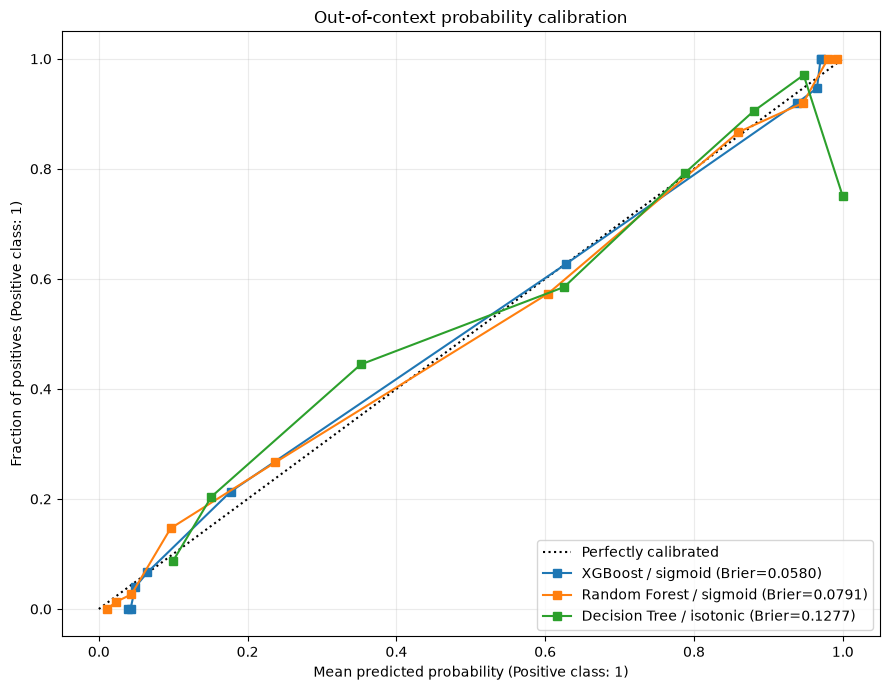

Best model by validation PR-AUC: XGBoost


,model,configuration,hyperparameters,calibration_method,brier_score,validation_pr_auc,validation_roc_auc
0,Decision Tree,1,"{""max_depth"": 6, ""min_samples_leaf"": 20}",isotonic,0.127725,0.869830,0.890172
1,Decision Tree,2,"{""max_depth"": 8, ""min_samples_leaf"": 10}",sigmoid,0.138902,0.814089,0.851410
2,Decision Tree,3,"{""max_depth"": 12, ""min_samples_leaf"": 5}",isotonic,0.149278,0.782136,0.832498
5,Random Forest,3,"{""max_depth"": 18, ""min_samples_leaf"": 2, ""n_es...",sigmoid,0.079076,0.961267,0.961213
4,Random Forest,2,"{""max_depth"": 14, ""min_samples_leaf"": 5, ""n_es...",sigmoid,0.083215,0.956734,0.957876
3,Random Forest,1,"{""max_depth"": 10, ""min_samples_leaf"": 10, ""n_e...",sigmoid,0.085714,0.955463,0.955886
7,XGBoost,3,"{""learning_rate"": 0.05, ""max_depth"": 4, ""n_est...",sigmoid,0.057955,0.973462,0.974210
8,XGBoost,2,"{""learning_rate"": 0.1, ""max_depth"": 6, ""n_esti...",sigmoid,0.058252,0.972956,0.973537
6,XGBoost,1,"{""learning_rate"": 0.1, ""max_depth"": 4, ""n_esti...",isotonic,0.061127,0.968967,0.972549


,model,configuration,hyperparameters,method,brier_score
1,Decision Tree,1,"{""max_depth"": 6, ""min_samples_leaf"": 20}",isotonic,0.127725
0,Decision Tree,1,"{""max_depth"": 6, ""min_samples_leaf"": 20}",sigmoid,0.130222
2,Decision Tree,2,"{""max_depth"": 8, ""min_samples_leaf"": 10}",sigmoid,0.138902
3,Decision Tree,2,"{""max_depth"": 8, ""min_samples_leaf"": 10}",isotonic,0.139198
5,Decision Tree,3,"{""max_depth"": 12, ""min_samples_leaf"": 5}",isotonic,0.149278
4,Decision Tree,3,"{""max_depth"": 12, ""min_samples_leaf"": 5}",sigmoid,0.151034
6,Random Forest,1,"{""max_depth"": 10, ""min_samples_leaf"": 10, ""n_e...",sigmoid,0.085714
7,Random Forest,1,"{""max_depth"": 10, ""min_samples_leaf"": 10, ""n_e...",isotonic,0.087159
8,Random Forest,2,"{""max_depth"": 14, ""min_samples_leaf"": 5, ""n_es...",sigmoid,0.083215
9,Random Forest,2,"{""max_depth"": 14, ""min_samples_leaf"": 5, ""n_es...",isotonic,0.084856


,model,hyperparameters,calibration_method,brier_score,validation_pr_auc,validation_roc_auc,threshold,accuracy,precision,recall,f1,false_positive_rate,false_negative_rate,false_positives,false_negatives
0,XGBoost,"{""learning_rate"": 0.05, ""max_depth"": 4, ""n_est...",sigmoid,0.057955,0.973462,0.974210,0.436,0.926862,0.925208,0.922652,0.923928,0.069231,0.077348,27,28
1,Random Forest,"{""max_depth"": 18, ""min_samples_leaf"": 2, ""n_es...",sigmoid,0.079076,0.961267,0.961213,0.493,0.890957,0.886740,0.886740,0.886740,0.105128,0.113260,41,41
2,Decision Tree,"{""max_depth"": 6, ""min_samples_leaf"": 20}",isotonic,0.127725,0.869830,0.890172,0.568,0.827128,0.818681,0.823204,0.820937,0.169231,0.176796,66,64


In [3]:
train_data = data[data["split"].eq("train")].reset_index(drop=True)
validation_data = data[data["split"].eq("validation")].reset_index(drop=True)
test_data = data[data["split"].eq("test")].reset_index(drop=True)

validation_splitter = GroupShuffleSplit(n_splits=1, train_size=0.5, random_state=SEED)
calibration_idx, threshold_idx = next(
    validation_splitter.split(
        validation_data,
        y=validation_data["out_of_context"],
        groups=validation_data["pair_id"],
    )
)
calibration_data = validation_data.iloc[calibration_idx].reset_index(drop=True)
threshold_data = validation_data.iloc[threshold_idx].reset_index(drop=True)

embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME)

def transform(frame, show_progress_bar=True):
    return preprocess_prompt_pairs(
        frame["system_prompt"].tolist(),
        frame["user_prompt"].tolist(),
        embedding_model,
        show_progress_bar=show_progress_bar,
    )

X_train = transform(train_data)
X_calibration = transform(calibration_data)
X_threshold = transform(threshold_data)
test_preprocessing_started = perf_counter()
X_test = transform(test_data)
preprocessing_latency_ms_per_sample = (
    (perf_counter() - test_preprocessing_started) * 1000 / len(test_data)
)
y_train = train_data["out_of_context"].to_numpy()
y_calibration = calibration_data["out_of_context"].to_numpy()
y_threshold = threshold_data["out_of_context"].to_numpy()
y_test = test_data["out_of_context"].to_numpy()
negative_count, positive_count = np.bincount(y_train)

hyperparameter_grids = {
    "Decision Tree": [
        {"max_depth": 6, "min_samples_leaf": 20},
        {"max_depth": 8, "min_samples_leaf": 10},
        {"max_depth": 12, "min_samples_leaf": 5},
    ],
    "Random Forest": [
        {"n_estimators": 200, "max_depth": 10, "min_samples_leaf": 10},
        {"n_estimators": 300, "max_depth": 14, "min_samples_leaf": 5},
        {"n_estimators": 400, "max_depth": 18, "min_samples_leaf": 2},
    ],
    "XGBoost": [
        {"n_estimators": 200, "max_depth": 4, "learning_rate": 0.10},
        {"n_estimators": 300, "max_depth": 6, "learning_rate": 0.10},
        {"n_estimators": 400, "max_depth": 4, "learning_rate": 0.05},
    ],
}


def build_estimator(model_name, parameters, internal_jobs):
    if model_name == "Decision Tree":
        return DecisionTreeClassifier(
            **parameters, class_weight="balanced", random_state=SEED
        )
    if model_name == "Random Forest":
        return RandomForestClassifier(
            **parameters,
            class_weight="balanced_subsample",
            n_jobs=internal_jobs,
            random_state=SEED,
        )
    return XGBClassifier(
        **parameters,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=negative_count / positive_count,
        eval_metric="logloss",
        tree_method="hist",
        n_jobs=internal_jobs,
        random_state=SEED,
    )


def evaluate_candidate(model_name, configuration_index, parameters, internal_jobs):
    pipeline = Pipeline([
        ("preprocessing", "passthrough"),
        ("classifier", build_estimator(model_name, parameters, internal_jobs)),
    ]).fit(X_train, y_train)

    calibration_candidates = {}
    calibration_rows_local = []
    for method in ("sigmoid", "isotonic"):
        calibrated_candidate = CalibratedClassifierCV(
            FrozenEstimator(pipeline), method=method
        ).fit(X_calibration, y_calibration)
        candidate_probability = calibrated_candidate.predict_proba(X_threshold)[:, 1]
        brier = brier_score_loss(y_threshold, candidate_probability)
        calibration_candidates[method] = (
            calibrated_candidate, candidate_probability, brier
        )
        calibration_rows_local.append({
            "model": model_name,
            "configuration": configuration_index,
            "hyperparameters": json.dumps(parameters, sort_keys=True),
            "method": method,
            "brier_score": brier,
        })

    best_method = min(
        calibration_candidates,
        key=lambda method: calibration_candidates[method][2],
    )
    calibrated_model, threshold_probability, best_brier = calibration_candidates[best_method]
    validation_pr_auc = average_precision_score(y_threshold, threshold_probability)
    validation_roc_auc = roc_auc_score(y_threshold, threshold_probability)
    tuning_row = {
        "model": model_name,
        "configuration": configuration_index,
        "hyperparameters": json.dumps(parameters, sort_keys=True),
        "calibration_method": best_method,
        "brier_score": best_brier,
        "validation_pr_auc": validation_pr_auc,
        "validation_roc_auc": validation_roc_auc,
    }
    candidate_result = {
        "parameters": parameters,
        "calibration_method": best_method,
        "model": calibrated_model,
        "probabilities": threshold_probability,
        "brier_score": best_brier,
        "validation_pr_auc": validation_pr_auc,
        "validation_roc_auc": validation_roc_auc,
    }
    return calibration_rows_local, tuning_row, candidate_result


calibrated_models = {}
selected_thresholds = {}
threshold_tables = {}
validation_probabilities = {}
calibration_rows = []
tuning_rows = []
model_selection_rows = []

for model_name, parameter_grid in hyperparameter_grids.items():
    candidate_workers = min(MAX_CANDIDATE_WORKERS, len(parameter_grid))
    internal_jobs = max(1, (os.cpu_count() or 1) // max(1, candidate_workers))
    tuned_candidates = []

    with ThreadPoolExecutor(max_workers=candidate_workers) as executor:
        futures = {
            executor.submit(
                evaluate_candidate,
                model_name,
                configuration_index,
                parameters,
                internal_jobs,
            ): (configuration_index, parameters)
            for configuration_index, parameters in enumerate(parameter_grid, start=1)
        }
        for future in as_completed(futures):
            calibration_rows_local, tuning_row, candidate_result = future.result()
            calibration_rows.extend(calibration_rows_local)
            tuning_rows.append(tuning_row)
            tuned_candidates.append(candidate_result)

    best_tuned_candidate = max(
        tuned_candidates,
        key=lambda item: (
            item["validation_pr_auc"],
            item["validation_roc_auc"],
            -item["brier_score"],
        ),
    )
    calibrated_model = best_tuned_candidate["model"]
    threshold_probability = best_tuned_candidate["probabilities"]
    selected_threshold, threshold_table = select_threshold(
        y_threshold, threshold_probability
    )
    threshold_metrics = metrics_at_threshold(
        y_threshold, threshold_probability, selected_threshold
    )
    calibrated_models[model_name] = calibrated_model
    selected_thresholds[model_name] = selected_threshold
    threshold_tables[model_name] = threshold_table.assign(model=model_name)
    validation_probabilities[model_name] = threshold_probability
    model_selection_rows.append({
        "model": model_name,
        "hyperparameters": json.dumps(best_tuned_candidate["parameters"], sort_keys=True),
        "calibration_method": best_tuned_candidate["calibration_method"],
        "brier_score": best_tuned_candidate["brier_score"],
        "validation_pr_auc": best_tuned_candidate["validation_pr_auc"],
        "validation_roc_auc": best_tuned_candidate["validation_roc_auc"],
        **threshold_metrics,
    })

calibration_comparison = pd.DataFrame(calibration_rows).sort_values(
    ["model", "configuration", "brier_score"]
)
hyperparameter_tuning = pd.DataFrame(tuning_rows).sort_values(
    ["model", "validation_pr_auc", "validation_roc_auc"],
    ascending=[True, False, False],
)
model_selection_comparison = pd.DataFrame(model_selection_rows).sort_values(
    ["validation_pr_auc", "validation_roc_auc"], ascending=False
).reset_index(drop=True)
best_model_name = model_selection_comparison.iloc[0]["model"]

fig, axis = plt.subplots(figsize=(9, 7))
for row in model_selection_comparison.itertuples():
    CalibrationDisplay.from_predictions(
        y_threshold,
        validation_probabilities[row.model],
        n_bins=10,
        strategy="quantile",
        name=f"{row.model} / {row.calibration_method} (Brier={row.brier_score:.4f})",
        ax=axis,
    )
axis.set_title("Out-of-context probability calibration")
axis.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "calibration_plot.png", dpi=160)
plt.show()

print(f"Best model by validation PR-AUC: {best_model_name}")
display(hyperparameter_tuning)
display(calibration_comparison)
display(model_selection_comparison)

## Test evaluation, latency and exports

Avaliacao final dos tres modelos no teste. A latencia de preprocessing e medida em lote uma vez; a latencia de `predict_proba` usa aquecimento e a mediana de cinco repeticoes. Ambas sao reportadas em milissegundos por amostra.

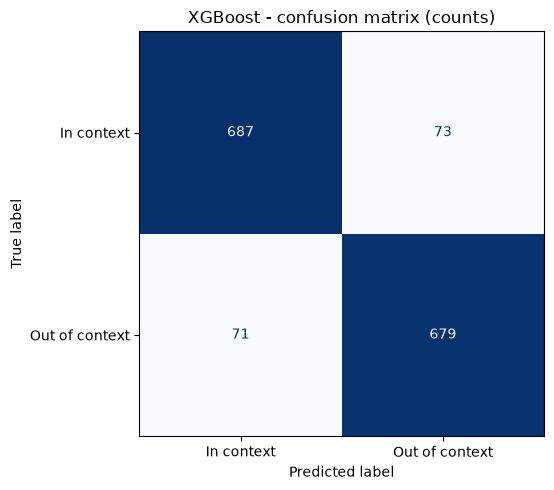

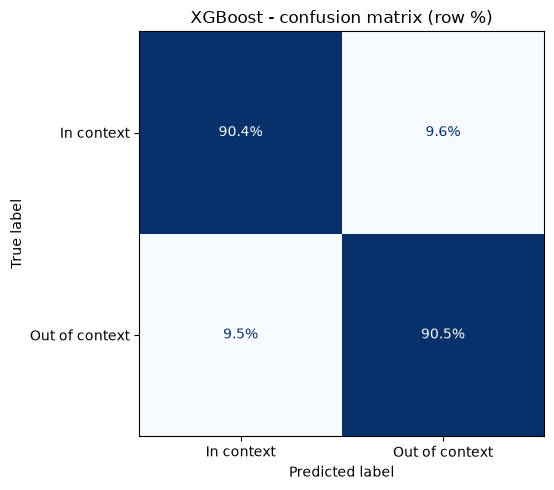

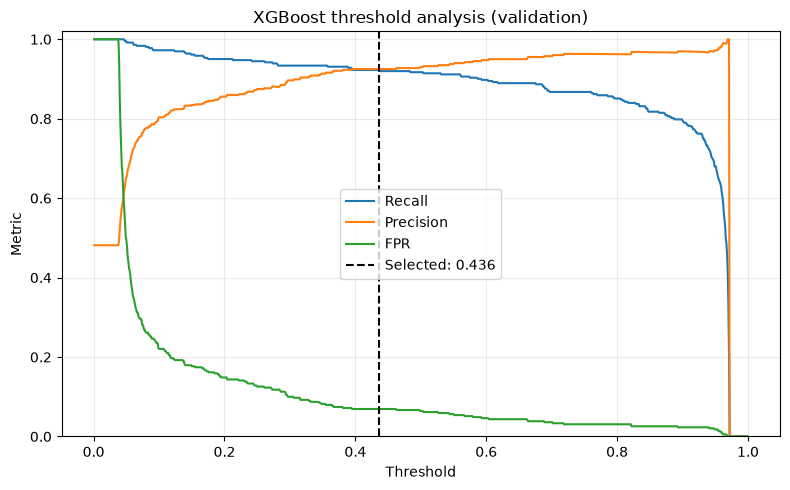

Selected model: XGBoost


,model,hyperparameters,selected_on_validation,calibration_method,threshold,accuracy,precision,recall,f1,false_positive_rate,false_negative_rate,false_positives,false_negatives,roc_auc,pr_auc,preprocessing_latency_ms_per_sample,model_latency_ms_per_sample,end_to_end_latency_ms_per_sample
0,XGBoost,"{""learning_rate"": 0.05, ""max_depth"": 4, ""n_est...",True,sigmoid,0.436,0.904636,0.902926,0.905333,0.904128,0.096053,0.094667,73,71,0.964247,0.963178,98.522895,0.004740,98.527635
1,Random Forest,"{""max_depth"": 18, ""min_samples_leaf"": 2, ""n_es...",False,sigmoid,0.493,0.869536,0.884562,0.848000,0.865895,0.109211,0.152000,83,114,0.947121,0.950863,98.522895,0.177074,98.699969
2,Decision Tree,"{""max_depth"": 6, ""min_samples_leaf"": 20}",False,isotonic,0.568,0.807947,0.797158,0.822667,0.809711,0.206579,0.177333,157,133,0.884030,0.876116,98.522895,0.001187,98.524082


,predicted_in_context,predicted_out_of_context
actual_in_context,687,73
actual_out_of_context,71,679


,predicted_in_context,predicted_out_of_context
actual_in_context,90.4%,9.6%
actual_out_of_context,9.5%,90.5%


In [4]:
test_probabilities_by_model = {
    model_name: model.predict_proba(X_test)[:, 1]
    for model_name, model in calibrated_models.items()
}
test_rows = []
for model_name, probabilities in test_probabilities_by_model.items():
    model_latency_ms_per_sample = measure_prediction_latency(
        calibrated_models[model_name], X_test
    )
    model_metrics = metrics_at_threshold(
        y_test, probabilities, selected_thresholds[model_name]
    )
    selection_row = model_selection_comparison[
        model_selection_comparison["model"].eq(model_name)
    ].iloc[0]
    test_rows.append({
        "model": model_name,
        "hyperparameters": selection_row["hyperparameters"],
        "selected_on_validation": model_name == best_model_name,
        "calibration_method": selection_row["calibration_method"],
        **model_metrics,
        "roc_auc": roc_auc_score(y_test, probabilities),
        "pr_auc": average_precision_score(y_test, probabilities),
        "preprocessing_latency_ms_per_sample": preprocessing_latency_ms_per_sample,
        "model_latency_ms_per_sample": model_latency_ms_per_sample,
        "end_to_end_latency_ms_per_sample": (
            preprocessing_latency_ms_per_sample + model_latency_ms_per_sample
        ),
    })
model_comparison = pd.DataFrame(test_rows).sort_values("pr_auc", ascending=False).reset_index(drop=True)

test_probabilities = test_probabilities_by_model[best_model_name]
selected_threshold = selected_thresholds[best_model_name]
threshold_table = threshold_tables[best_model_name].drop(columns="model")
predictions = (test_probabilities >= selected_threshold).astype(int)
count_matrix = confusion_matrix(y_test, predictions, labels=[0, 1])
percentage_matrix = confusion_matrix(y_test, predictions, labels=[0, 1], normalize="true")
labels = ["In context", "Out of context"]

fig, axis = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(count_matrix, display_labels=labels).plot(
    ax=axis, cmap="Blues", colorbar=False, values_format="d"
)
axis.set_title(f"{best_model_name} - confusion matrix (counts)")
fig.tight_layout()
fig.savefig(RESULTS_DIR / "confusion_matrix_counts.png", dpi=160)
plt.show()

fig, axis = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(percentage_matrix, display_labels=labels).plot(
    ax=axis, cmap="Blues", colorbar=False, values_format=".1%"
)
axis.set_title(f"{best_model_name} - confusion matrix (row %)")
fig.tight_layout()
fig.savefig(RESULTS_DIR / "confusion_matrix_percentages.png", dpi=160)
plt.show()

fig, axis = plt.subplots(figsize=(8, 5))
axis.plot(threshold_table["threshold"], threshold_table["recall"], label="Recall")
axis.plot(threshold_table["threshold"], threshold_table["precision"], label="Precision")
axis.plot(threshold_table["threshold"], threshold_table["false_positive_rate"], label="FPR")
axis.axvline(selected_threshold, color="black", linestyle="--", label=f"Selected: {selected_threshold:.3f}")
axis.set(xlabel="Threshold", ylabel="Metric", ylim=(0, 1.02), title=f"{best_model_name} threshold analysis (validation)")
axis.grid(alpha=0.25)
axis.legend()
fig.tight_layout()
fig.savefig(RESULTS_DIR / "threshold_analysis.png", dpi=160)
plt.show()

confusion_counts = pd.DataFrame(count_matrix, index=["actual_in_context", "actual_out_of_context"], columns=["predicted_in_context", "predicted_out_of_context"])
confusion_percentages = pd.DataFrame(percentage_matrix, index=["actual_in_context", "actual_out_of_context"], columns=["predicted_in_context", "predicted_out_of_context"])
with pd.ExcelWriter(RESULTS_DIR / "results.xlsx", engine="openpyxl") as writer:
    dataset_summary.to_excel(writer, sheet_name="dataset_distribution", index=False)
    hyperparameter_tuning.to_excel(writer, sheet_name="hyperparameter_tuning", index=False)
    calibration_comparison.to_excel(writer, sheet_name="calibration", index=False)
    model_selection_comparison.to_excel(writer, sheet_name="validation_comparison", index=False)
    model_comparison.to_excel(writer, sheet_name="test_comparison", index=False)
    threshold_table.to_excel(writer, sheet_name="threshold_analysis", index=False)
    confusion_counts.to_excel(writer, sheet_name="confusion_counts")
    confusion_percentages.to_excel(writer, sheet_name="confusion_percentages")

print(f"Selected model: {best_model_name}")
display(model_comparison)
display(confusion_counts)
display(confusion_percentages.style.format("{:.1%}"))

In [5]:
expected_results = {
    RESULTS_DIR / "calibration_plot.png",
    RESULTS_DIR / "confusion_matrix_counts.png",
    RESULTS_DIR / "confusion_matrix_percentages.png",
    RESULTS_DIR / "threshold_analysis.png",
    RESULTS_DIR / "results.xlsx",
}
missing_results = [path for path in expected_results if not path.exists()]
assert not missing_results, f"Missing results: {missing_results}"
assert model_comparison[[
    "accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"
]].apply(lambda column: column.between(0.0, 1.0).all()).all()
assert model_comparison[[
    "preprocessing_latency_ms_per_sample",
    "model_latency_ms_per_sample",
    "end_to_end_latency_ms_per_sample",
]].gt(0.0).all().all()
assert len(hyperparameter_tuning) == sum(
    len(configurations) for configurations in hyperparameter_grids.values()
)
print("Experiment completed successfully")
print("\n".join(str(path.relative_to(PROJECT_ROOT)) for path in sorted(expected_results)))

Experiment completed successfully
experiments/out_of_context/results/calibration_plot.png
experiments/out_of_context/results/confusion_matrix_counts.png
experiments/out_of_context/results/confusion_matrix_percentages.png
experiments/out_of_context/results/results.xlsx
experiments/out_of_context/results/threshold_analysis.png
